In [1]:
import torchvision
import numpy as np
import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

In [2]:
# Import autoencoder utility tools
from mnist_autoencoders.data.utils import transform, output_to_image
from mnist_autoencoders.models.AutoEncoder import AutoEncoder
from mnist_autoencoders.models.VAE import VAE

In [3]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = "cuda"  # Hack for ssh device detection mismatch
cfg = OmegaConf.load("../configs/vae.yaml")

In [4]:
interpolation_length = 10
latent_dims = cfg.model.latent_dim

In [5]:
# Initialise networks
vae = VAE(cfg).to(device)
vae.load_state_dict(
    torch.load(
        "../models/vae_v1/checkpoint_epoch_50.pt",
        map_location=device,
        weights_only=False,
    )
)
v_encoder = vae.encoder.to(device)
v_decoder = vae.decoder.to(device)
autoencoder = AutoEncoder(cfg).to(device)
autoencoder.load_state_dict(
    torch.load(
        "../models/autoencoder_v2/checkpoint_epoch_50.pt",
        map_location=device,
        weights_only=False,
    )
)
encoder = autoencoder.encoder.to(device)
decoder = autoencoder.decoder.to(device)

In [6]:
# Download mnist data
inference_data = torchvision.datasets.MNIST(
    "../data", download=True, transform=transform
)

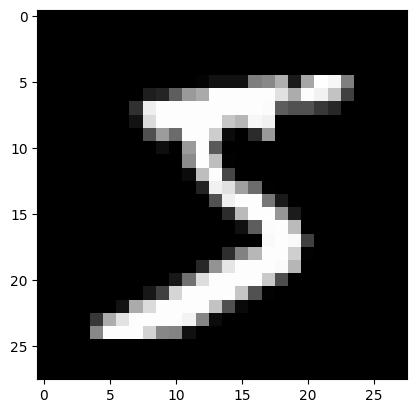

In [7]:
# Gather two mnist images
image_1 = inference_data[0][0]  # 1x28x28
image_2 = inference_data[1][0]  # 1x28x28
plt.imshow(image_1.permute(1, 2, 0), cmap="gray")

In [8]:
# Convert images to b, c, w, h form
image_1 = torch.reshape(image_1, (1, 1, 28, 28)).to(device)
image_2 = torch.reshape(image_2, (1, 1, 28, 28)).to(device)

In [9]:
# Encode both into latent tensors
latent_1, latent_2 = encoder(image_1), encoder(image_2)
v_latent_1, v_latent_2 = v_encoder(image_1)[0], v_encoder(image_2)[0]
latents = {"ae": [latent_1, latent_2], "vae": [v_latent_1, v_latent_2]}

In [10]:
# Interpolate latent tensors
batch = np.empty((2, interpolation_length, latent_dims))
with torch.inference_mode():
    for i, model in enumerate(["ae", "vae"]):
        latent_1 = latents[model][0].cpu()
        latent_2 = latents[model][1].cpu()
        for j in range(interpolation_length):
            batch[i][j] = (
                latent_1 + (j * (latent_2 - latent_1)) / interpolation_length - 1
            )

In [11]:
# Decode into interpolation images (normalised)
# TODO:
ae_interpolation = torch.from_numpy(batch[0]).to(device)
vae_interpolation = torch.from_numpy(batch[1]).to(device)
ae_output = decoder(ae_interpolation.to(torch.float32))
vae_output = v_decoder(vae_interpolation.to(torch.float32))
output = torch.stack((ae_output, vae_output))

In [12]:
# Convert to 0, 255
images = output_to_image(output).cpu()

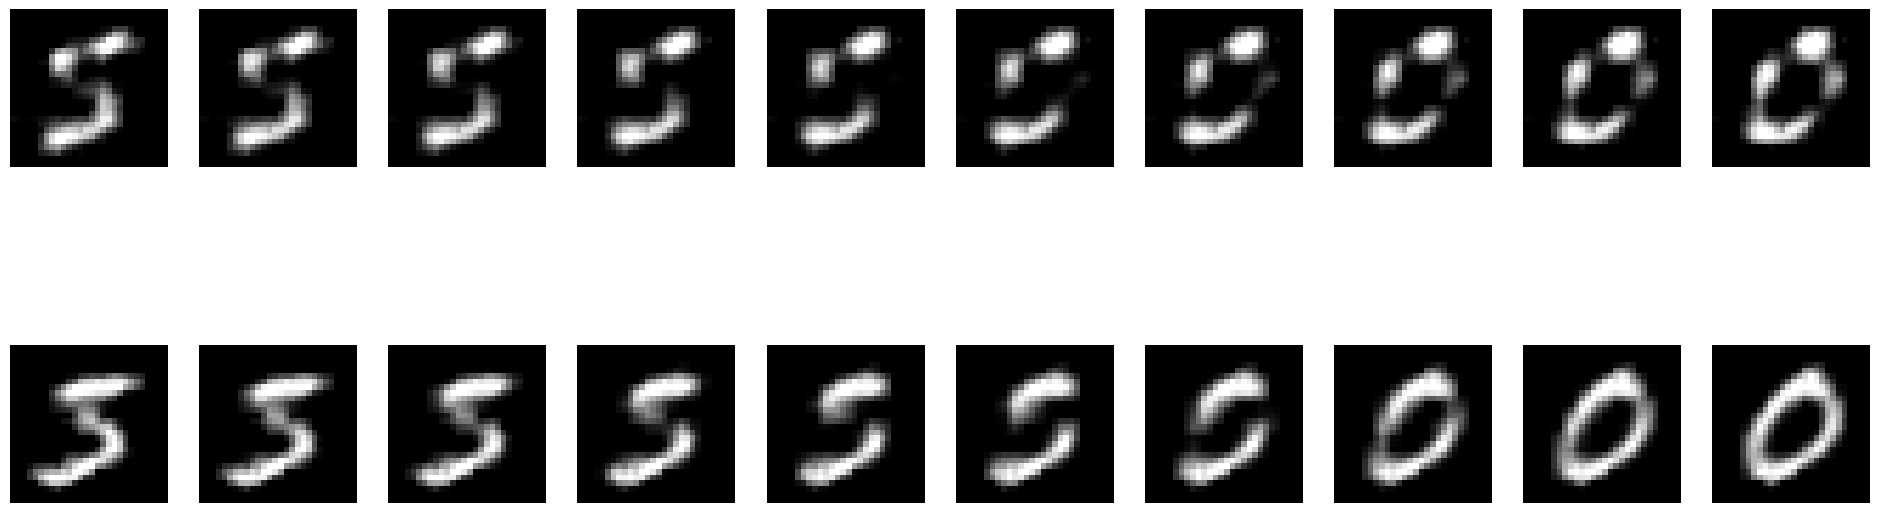

In [13]:
# Plot output in 1, 10 figure
fig, axes = plt.subplots(2, 10, figsize=(24, 8))
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.imshow(images[i][j].permute(1, 2, 0), cmap="gray")
        ax.axis("off")

## Observations
In the above interpolation I can see the transition from a 5 to a 0. Honestly not much looks wrong with it... Either I'm missing a key detail or MNIST is not a good example for showing the lack of meaning within latent dimensions.

After a brief AI chat, I have reached the conclusion that there is no continuity between these two encodings. This means that if sampling was attempted, most points would be gibberish and not interpretable digits.

On the VAE comparison: I can see that coherence is far better maintained- each frame is interpretable! This is due to the overlapping latent space from the learnt gaussian instead of inidividual points